In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abysm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [70]:
data=pd.read_csv('spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [71]:
data.shape

(5171, 4)

<Axes: xlabel='label', ylabel='count'>

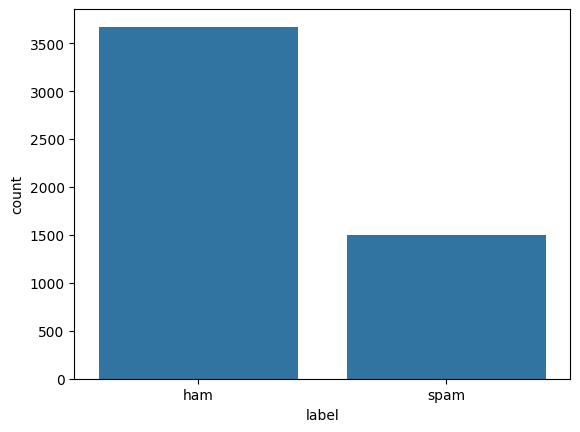

In [72]:
sns.countplot(x='label',data=data)

Text(0.5, 1.0, 'Balanced Distribution of Spam and Ham Emails')

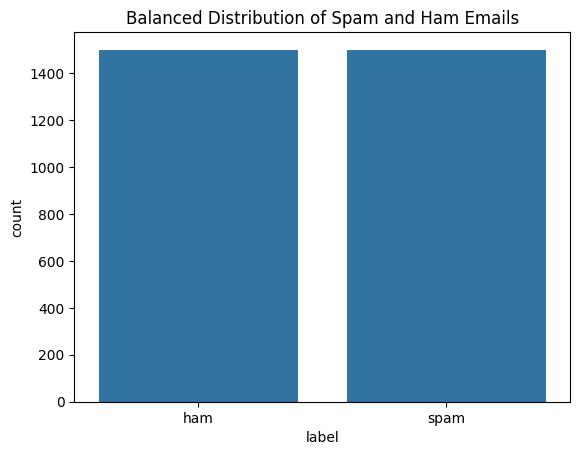

In [73]:
ham=data[data['label']=='ham']
spam=data[data['label']=='spam']

haml=ham.sample(n=len(spam),random_state=42)
bdata=pd.concat([haml,spam]).reset_index(drop=True)
sns.countplot(data=bdata,x='label')
plt.title('Balanced Distribution of Spam and Ham Emails')

CLEANING THE TEXT

In [74]:
bdata['text']=bdata['text'].str.replace('Subject','')

In [75]:
punctuations_list=string.punctuation
def remove_punctuations(text):
    temp=str.maketrans('','',punctuations_list) #creating translation table
    return text.translate(temp)                 #translating
bdata['text']=bdata['text'].apply(lambda x:remove_punctuations(x))
bdata.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [76]:
def remove_stopwords(text):
    stop_words=stopwords.words('english')
    imp_words=[]
    for word in str(text).split():
        word=word.lower()
        if word not in stop_words:
            imp_words.append(word)
    output=" ".join(imp_words)
    return output

bdata['text']=bdata['text'].apply(lambda text:remove_stopwords(text))
bdata.head()



,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


WORDCLOUD VISUALIZATION

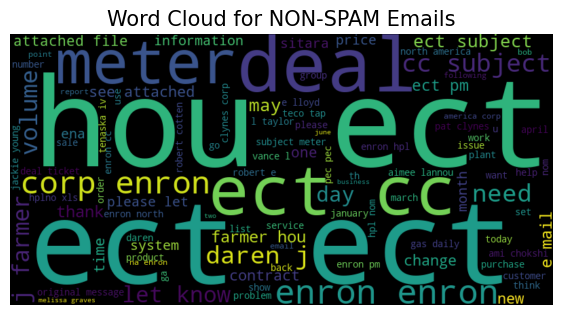

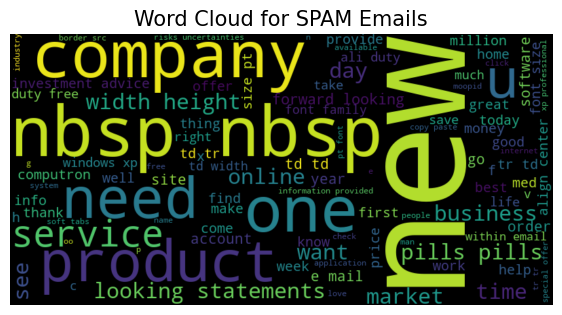

In [77]:
def plot_wordcloud(data,typ):
    email_corpus=" ".join(data['text'])
    wc=WordCloud(background_color='black',max_words=100,width=800,height=400).generate(email_corpus)
    plt.figure(figsize=(7,7))
    plt.imshow(wc,interpolation='bilinear')
    plt.title(f'Word Cloud for {typ} Emails',fontsize=15)
    plt.axis('off')
    plt.show()

plot_wordcloud(bdata[bdata['label']=='ham'],typ='NON-SPAM')
plot_wordcloud(bdata[bdata['label']=='spam'],typ='SPAM')


TOKENIZATION AND PADDING

In [78]:
X_train,X_test,Y_train,Y_test=train_test_split(bdata['text'],bdata['label'],test_size=0.2,random_state=42)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
train_sequences=tokenizer.texts_to_sequences(X_train)
test_sequences=tokenizer.texts_to_sequences(X_test)

max_length=100
train_sequences=pad_sequences(train_sequences,maxlen=max_length,padding='post',truncating='post')
test_sequences=pad_sequences(test_sequences,maxlen=max_length,padding='post',truncating='post')

Y_train=(Y_train=='spam').astype(int)
Y_test=(Y_test=='spam').astype(int)

SAVING TOKENIZER

In [79]:
import pickle
with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

DEFINE MODEL

In [80]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index)+1,
                              output_dim=32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
              )

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 32)        │     1,274,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,278,625 (4.88 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

TRAIN THE MODEL

In [81]:
es=EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)
lr=ReduceLROnPlateau(patience=3,monitor='val_loss',factor=0.5,verbose=1)

history=model.fit(
    train_sequences,Y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[lr,es],
    shuffle=True
    )

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5532 - loss: 0.6904 - val_accuracy: 0.6687 - val_loss: 0.6710 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8801 - loss: 0.3443 - val_accuracy: 0.9333 - val_loss: 0.2144 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9510 - loss: 0.1928 - val_accuracy: 0.9417 - val_loss: 0.2459 - learning_rate: 0.0010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9593 - loss: 0.1713 - val_accuracy: 0.9417 - val_loss: 0.2196 - learning_rate: 0.0010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9755 - loss: 0.1205
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9698 - loss: 0.1375 - val_accuracy: 0.9417 - val_loss: 0.2278 - learning_rate: 0.0010
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9698 - loss: 0.1342 - val_accu

In [82]:
test_loss,test_accuracy=model.evaluate(test_sequences,Y_test)
print('Test loss :',test_loss)
print('Test accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9500 - loss: 0.2114
Test loss : 0.21141253411769867
Test accuracy : 0.949999988079071


In [83]:
model.save('spam_model.keras',include_optimizer=False)

In [84]:
import tensorflow as tf
tf.keras.models.load_model("spam_model.keras", compile=False)

<Sequential name=sequential_4, built=True>